In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [20]:
df = pd.read_csv('../data/raw_hr_data.csv')
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [21]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [22]:
df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'])
print(df.shape)

(1470, 32)


In [23]:
df['Attrition_Binary'] = df['Attrition'].map({'Yes': 1, 'No': 0})

total = len(df)
left = df['Attrition_Binary'].sum()
rate = (left / total) * 100

print(f"Total: {total}")
print(f"Left: {left}")
print(f"Attrition Rate: {rate:.1f}%")

Total: 1470
Left: 237
Attrition Rate: 16.1%


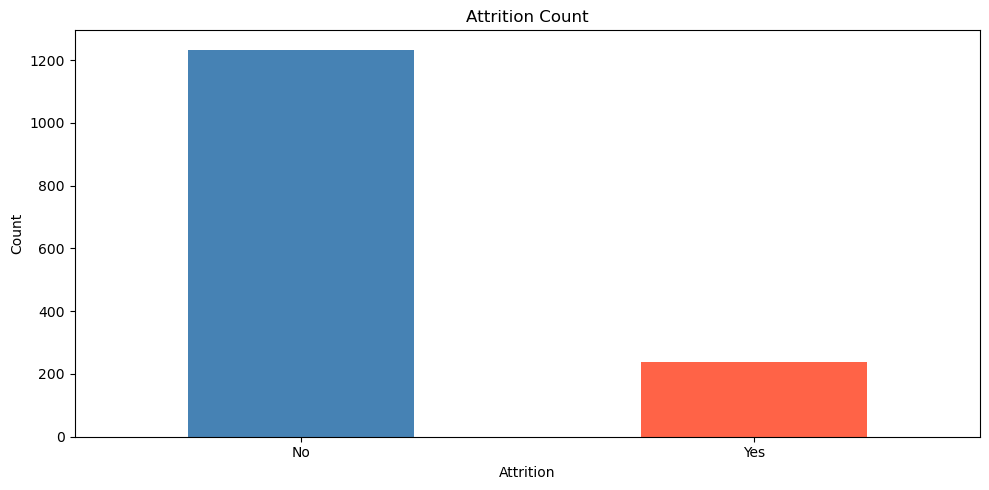

In [24]:
df['Attrition'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Attrition Count')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/plot_attrition.png')
plt.show()

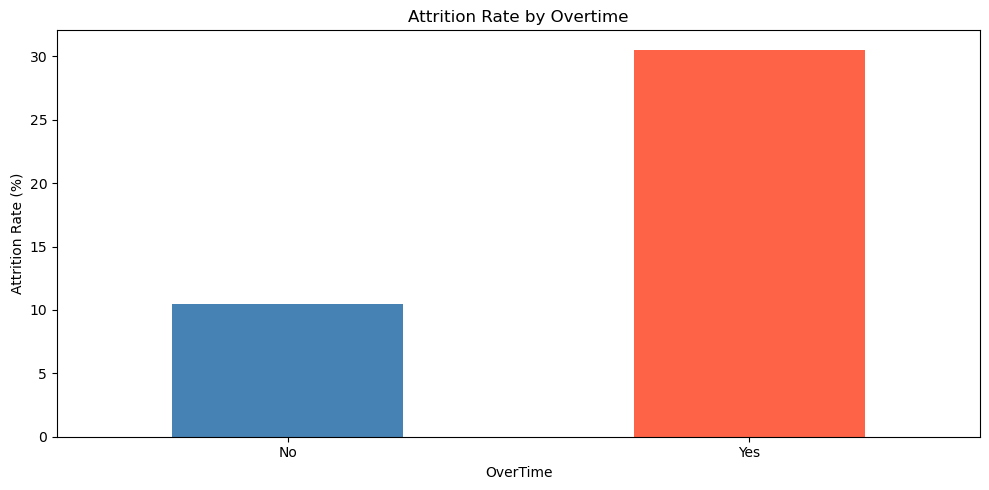

In [25]:
ot = df.groupby('OverTime')['Attrition_Binary'].mean() * 100
ot.plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Attrition Rate by Overtime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/plot_overtime.png')
plt.show()

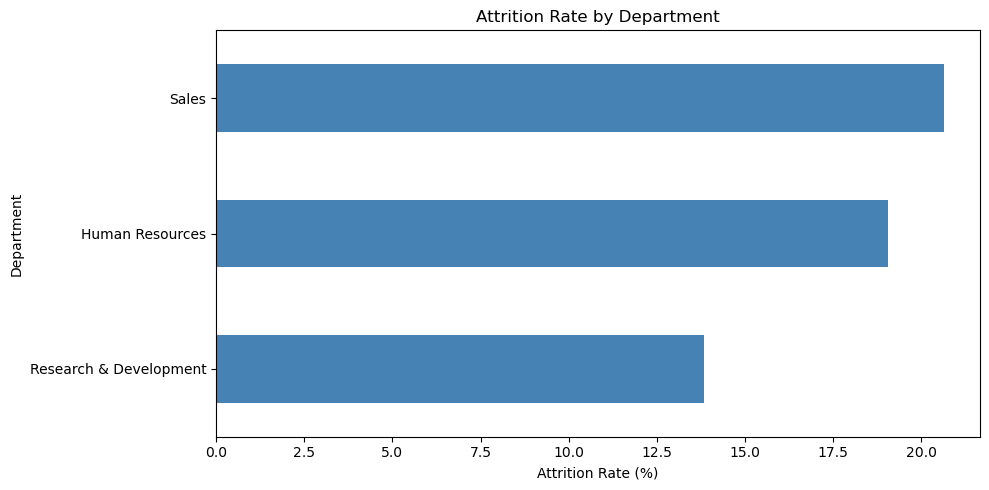

In [26]:
dept = df.groupby('Department')['Attrition_Binary'].mean() * 100
dept.sort_values().plot(kind='barh', color='steelblue')
plt.title('Attrition Rate by Department')
plt.xlabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('../data/plot_dept.png')
plt.show()

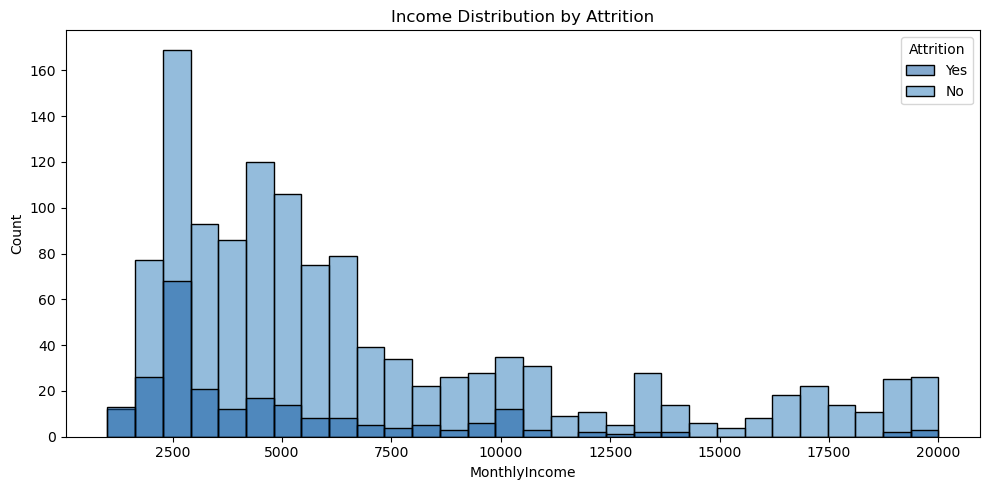

Attrition
No     5204.0
Yes    3202.0
Name: MonthlyIncome, dtype: float64


In [27]:
sns.histplot(data=df, x='MonthlyIncome', hue='Attrition', bins=30)
plt.title('Income Distribution by Attrition')
plt.tight_layout()
plt.savefig('../data/plot_income.png')
plt.show()

print(df.groupby('Attrition')['MonthlyIncome'].median())

In [28]:
df.to_csv('../data/cleaned_hr_data.csv', index=False)
print("Done! Shape:", df.shape)

Done! Shape: (1470, 33)
